# Stage 2 GAN comparison — AC-GAN vs. Projection discriminator

This notebook trains and compares the **two Stage 2 GANs** and evaluates them **with and without the frozen classifier**, in one place.

**The two GANs** (identical generator + recipe; only the discriminator/objective differs):
- **AC-GAN improved** (`--disc acgan`) — twin validity+class heads, BCE + cross-entropy. The generator can satisfy the auxiliary classifier with a cheap label *fingerprint* (Stage 1 found synthetic-only transfer at 55%, below the majority floor).
- **Projection** (`--disc projection`) — no classifier head; conditions via the inner product `⟨embed(y), φ(x)⟩` and hinge loss. Nothing to game with a fingerprint, so the generator must make class *features* match real class-y images.

**The 2×2 downstream test** — each synthetic pool is fed to:
- **frozen** VGG head (`train_classifier.py`, the paper's design), and
- **unfrozen** Track A encoder (`stage2/train_stage2.py --unfreeze-blocks 2`), which actually has the capacity for augmentation to help.

The real success metric is not FID — it is whether the projection pool lifts **CNN-SA** (especially in the unfrozen column) more than AC-GAN does.

> Run cells top to bottom. The two training cells take ~55 s/epoch on an M-series GPU (300 epochs ≈ 4.5 h each); checkpoints land every 50 epochs so you can stop early and still evaluate.

## 0. Setup

In [1]:
import os, sys, glob, re, subprocess
from types import SimpleNamespace

# Run from the project root so `covidgan` / `stage2` import and relative paths resolve.
PROJECT_ROOT = "/Users/hilafishman/PycharmProjects/CovidGAN-Pytorch"
if os.path.isdir(PROJECT_ROOT):
    os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Auto-reload the stage2 modules if you edit them while the kernel is live.
%load_ext autoreload
%autoreload 2

from covidgan.models import pick_device
print("cwd:", os.getcwd())
print("device:", pick_device())

cwd: /Users/hilafishman/PycharmProjects/CovidGAN-Pytorch
device: mps


## 1. Configure

`make_args` builds the argument namespace the trainer expects, so training runs inline (with a live tqdm bar) instead of shelling out.

In [2]:
EPOCHS = 300          # ~4.5 h/GAN on M-series; 200 is usually enough with this recipe
BATCH_SIZE = 64
MANIFEST = "data/manifest.csv"   # same-source primary reconstruction split

# Defaults mirror stage2/train_gan_manual.py's argparse; override any per call.
_GAN_DEFAULTS = dict(
    disc="projection", manifest=MANIFEST, out_dir="runs/gan_projection",
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=2e-4, g_lr=None, d_lr=None, beta1=0.5,
    noise_std=1.0, diffaugment="color,translation,cutout", seed=0, workers=2,
    sample_every=25, checkpoint_every=50, device="auto", cache=True, cpu=False, resume=None,
)

def make_args(**overrides):
    cfg = dict(_GAN_DEFAULTS); cfg.update(overrides)
    return SimpleNamespace(**cfg)

from stage2.train_gan_manual import train as train_gan

## 2. Train the Projection GAN (headline change)

Resume a stopped run by adding `resume="runs/gan_projection/checkpoints/covidgan_epoch0150.pt"` to `make_args(...)`.

In [3]:
train_gan(make_args(disc="projection", out_dir="runs/gan_projection", epochs=EPOCHS))

device: mps  disc: projection  seed: 0  policy: 'color,translation,cutout'  noise_std: 1.0
training images: 932  batches/epoch: 14
G params: 22,247,542  D params: 1,570,113


epoch    1/300  D_loss=1.2526  G_loss=1.0398  [0:22 elapsed, ETA 1:52:08]


epoch    2/300  D_loss=1.0402  G_loss=0.8200  [0:45 elapsed, ETA 1:52:09]


epoch    3/300  D_loss=0.9345  G_loss=0.7374  [1:08 elapsed, ETA 1:52:46]


epoch    4/300  D_loss=0.5438  G_loss=1.1828  [1:32 elapsed, ETA 1:53:56]


...

epoch  297/300  D_loss=1.6896  G_loss=0.3696  [2:19:06 elapsed, ETA 1:24]


epoch  298/300  D_loss=1.6933  G_loss=0.1454  [2:19:38 elapsed, ETA 0:56]


epoch  299/300  D_loss=1.6754  G_loss=0.1301  [2:20:09 elapsed, ETA 0:28]


epoch  300/300  D_loss=1.6699  G_loss=0.1421  [2:20:40 elapsed, ETA 0:00]


done. final checkpoint: runs/gan_projection/checkpoints/covidgan_final.pt


## 2b. (optional) Continue the Projection GAN to 600 epochs

**Resumes** from the 300-epoch checkpoint and trains 300→600 — it does *not* restart. The 300-epoch weights are **preserved**: `covidgan_epoch0300.pt` is never overwritten (only `covidgan_final.pt` advances to 600), so the 300-epoch model stays available for a 300-vs-600 comparison.

To keep the 300-epoch synthetic pool intact, generate the 600-epoch pool into a **separate** folder afterwards:
```bash
python -m stage2.generate_improved --checkpoint runs/gan_projection/checkpoints/covidgan_epoch0600.pt --out-dir data/synth_projection_600
```

In [10]:
# OPTIONAL: resume projection 300 -> 600. Loads covidgan_epoch0300.pt and continues;
# writes new checkpoints 0350..0600. The 300-epoch checkpoint is kept.
CKPT_300 = "runs/gan_projection/checkpoints/covidgan_epoch0300.pt"
assert os.path.exists(CKPT_300), "Train the 300-epoch projection GAN first (section 2)."
train_gan(make_args(disc="projection", out_dir="runs/gan_projection", epochs=600, resume=CKPT_300))

device: mps  disc: projection  seed: 0  policy: 'color,translation,cutout'  noise_std: 1.0
training images: 932  batches/epoch: 14
G params: 22,247,542  D params: 1,570,113
resumed from runs/gan_projection/checkpoints/covidgan_epoch0300.pt at epoch 300


epoch  301/600  D_loss=1.6876  G_loss=0.2337  [0:51 elapsed, ETA 4:16:30]


epoch  302/600  D_loss=1.6300  G_loss=0.2304  [1:46 elapsed, ETA 4:23:56]


epoch  303/600  D_loss=1.6364  G_loss=0.3559  [2:40 elapsed, ETA 4:24:32]


epoch  304/600  D_loss=1.6540  G_loss=0.2660  [3:31 elapsed, ETA 4:21:18]


...

epoch  597/600  D_loss=1.6206  G_loss=0.3080  [3:00:30 elapsed, ETA 1:49]


epoch  598/600  D_loss=1.6512  G_loss=0.2445  [3:01:00 elapsed, ETA 1:12]


epoch  599/600  D_loss=1.6474  G_loss=0.1981  [3:01:30 elapsed, ETA 0:36]


epoch  600/600  D_loss=1.6588  G_loss=0.2174  [3:02:00 elapsed, ETA 0:00]


done. final checkpoint: runs/gan_projection/checkpoints/covidgan_final.pt


## 3. Train the AC-GAN improved baseline (to compare against)

In [4]:
train_gan(make_args(disc="acgan", out_dir="runs/gan_acgan", epochs=EPOCHS))

device: mps  disc: acgan  seed: 0  policy: 'color,translation,cutout'  noise_std: 1.0
training images: 932  batches/epoch: 14
G params: 22,247,542  D params: 1,643,843


epoch    1/300  D_loss=2.6442  G_loss=1.4940  [0:31 elapsed, ETA 2:36:18]


epoch    2/300  D_loss=2.5163  G_loss=1.8170  [1:03 elapsed, ETA 2:36:54]


epoch    3/300  D_loss=2.5515  G_loss=1.6807  [1:34 elapsed, ETA 2:36:13]


epoch    4/300  D_loss=2.4973  G_loss=1.4320  [2:06 elapsed, ETA 2:35:58]


...

epoch  297/300  D_loss=1.7797  G_loss=0.9075  [2:32:10 elapsed, ETA 1:32]


epoch  298/300  D_loss=1.7777  G_loss=0.9072  [2:32:41 elapsed, ETA 1:01]


epoch  299/300  D_loss=1.7632  G_loss=0.9043  [2:33:11 elapsed, ETA 0:30]


epoch  300/300  D_loss=1.8052  G_loss=0.9206  [2:33:42 elapsed, ETA 0:00]


done. final checkpoint: runs/gan_acgan/checkpoints/covidgan_final.pt


## 4. Preview the latest samples from each GAN

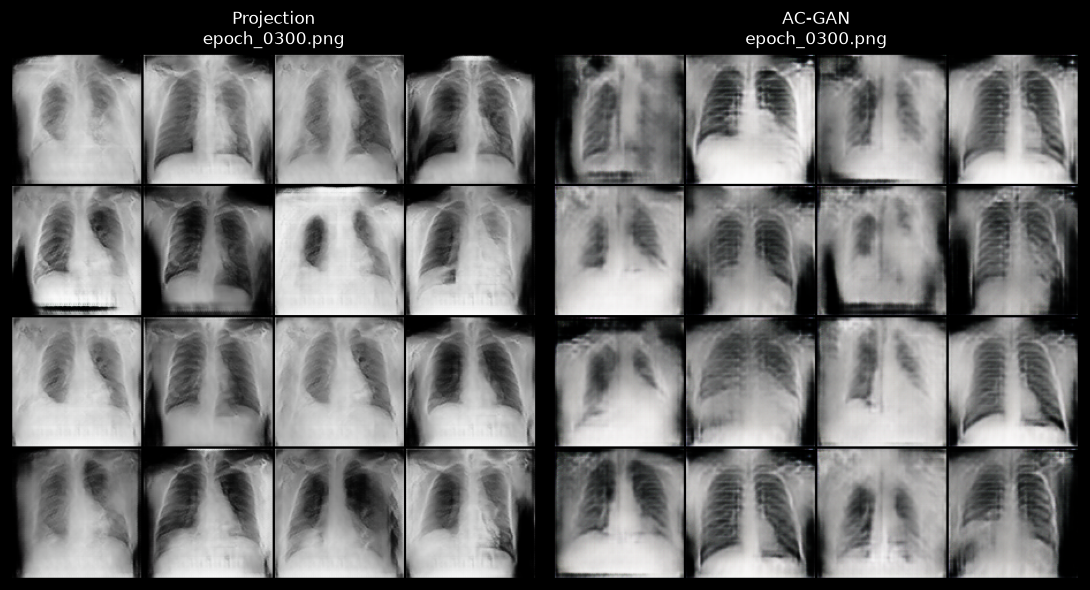

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def latest_sample(run_dir):
    pngs = sorted(glob.glob(f"{run_dir}/samples/epoch_*.png"))
    return pngs[-1] if pngs else None

fig, axes = plt.subplots(1, 2, figsize=(11, 6))
for ax, (title, run_dir) in zip(axes, [("Projection", "runs/gan_projection"), ("AC-GAN", "runs/gan_acgan")]):
    p = latest_sample(run_dir)
    ax.set_title(f"{title}\n{os.path.basename(p) if p else '(no samples yet)'}")
    ax.axis("off")
    if p:
        ax.imshow(mpimg.imread(p))
plt.tight_layout(); plt.show()

## 5. Generate a synthetic pool from each GAN

Same sampler for both (`generate_improved` rebuilds the shared `ImprovedGenerator`). Counts match the paper's pool (1669 COVID + 1399 Normal).

In [6]:
def sh(cmd):
    print("$", " ".join(cmd))
    r = subprocess.run(cmd, text=True, capture_output=True)
    print(r.stdout[-2000:]);  print(r.stderr[-800:]) if r.returncode else None
    if r.returncode: raise RuntimeError(f"exit {r.returncode}")

sh([sys.executable, "-m", "stage2.generate_improved",
    "--checkpoint", "runs/gan_projection/checkpoints/covidgan_final.pt",
    "--out-dir", "data/synth_projection"])
sh([sys.executable, "-m", "stage2.generate_improved",
    "--checkpoint", "runs/gan_acgan/checkpoints/covidgan_final.pt",
    "--out-dir", "data/synth_acgan"])

$ /Users/hilafishman/PycharmProjects/CovidGAN-Pytorch/.venv/bin/python -m stage2.generate_improved --checkpoint runs/gan_projection/checkpoints/covidgan_final.pt --out-dir data/synth_projection
covid: wrote 1669 images to data/synth_projection/covid
normal: wrote 1399 images to data/synth_projection/normal

$ /Users/hilafishman/PycharmProjects/CovidGAN-Pytorch/.venv/bin/python -m stage2.generate_improved --checkpoint runs/gan_acgan/checkpoints/covidgan_final.pt --out-dir data/synth_acgan
covid: wrote 1669 images to data/synth_acgan/covid
normal: wrote 1399 images to data/synth_acgan/normal



## 6. The 2×2 comparison table

Runs 6 classifiers: an AD baseline (real only) + SA with each pool, once **frozen** and once **unfrozen**, then parses accuracy and COVID recall from each `metrics.txt`.

In [7]:
def run_eval(name, classifier, mode, synth_dir=None):
    out_dir = f"runs/{name}"
    if classifier == "frozen":
        cmd = [sys.executable, "train_classifier.py", "--manifest", MANIFEST, "--mode", mode, "--out-dir", out_dir]
    else:  # unfrozen Track A encoder (top 2 VGG blocks)
        cmd = [sys.executable, "-m", "stage2.train_stage2", "--manifest", MANIFEST, "--mode", mode,
               "--unfreeze-blocks", "2", "--out-dir", out_dir]
    if mode == "sa":
        cmd += ["--synthetic-dir", synth_dir]
    print("$", " ".join(cmd))
    r = subprocess.run(cmd, text=True, capture_output=True)
    if r.returncode:
        print(r.stdout[-1500:]); print(r.stderr[-1500:]); raise RuntimeError(f"exit {r.returncode}")
    txt = open(f"{out_dir}/metrics.txt").read()
    acc = float(re.search(r"accuracy:\s*([\d.]+)%", txt).group(1))
    covid_recall = float(re.search(r"covid\s+[\d.]+\s+([\d.]+)", txt).group(1))
    print(f"  -> {name}: acc {acc:.2f}%  covid recall {covid_recall:.2f}")
    return {"accuracy": acc, "covid_recall": covid_recall}

results = {}
for classifier in ["frozen", "unfrozen"]:
    results[(classifier, "AD (real only)")]   = run_eval(f"{classifier}_ad",         classifier, "ad")
    results[(classifier, "SA + AC-GAN")]      = run_eval(f"{classifier}_sa_acgan",   classifier, "sa", "data/synth_acgan")
    results[(classifier, "SA + Projection")]  = run_eval(f"{classifier}_sa_proj",    classifier, "sa", "data/synth_projection")

$ /Users/hilafishman/PycharmProjects/CovidGAN-Pytorch/.venv/bin/python train_classifier.py --manifest data/manifest.csv --mode ad --out-dir runs/frozen_ad
  -> frozen_ad: acc 90.62%  covid recall 0.88
$ /Users/hilafishman/PycharmProjects/CovidGAN-Pytorch/.venv/bin/python train_classifier.py --manifest data/manifest.csv --mode sa --out-dir runs/frozen_sa_acgan --synthetic-dir data/synth_acgan
  -> frozen_sa_acgan: acc 90.10%  covid recall 0.86
$ /Users/hilafishman/PycharmProjects/CovidGAN-Pytorch/.venv/bin/python train_classifier.py --manifest data/manifest.csv --mode sa --out-dir runs/frozen_sa_proj --synthetic-dir data/synth_projection
  -> frozen_sa_proj: acc 90.10%  covid recall 0.82
$ /Users/hilafishman/PycharmProjects/CovidGAN-Pytorch/.venv/bin/python -m stage2.train_stage2 --manifest data/manifest.csv --mode ad --unfreeze-blocks 2 --out-dir runs/unfrozen_ad
  -> unfrozen_ad: acc 95.31%  covid recall 0.92
$ /Users/hilafishman/PycharmProjects/CovidGAN-Pytorch/.venv/bin/python -m st

In [9]:
import pandas as pd

cols = ["AD (real only)", "SA + AC-GAN", "SA + Projection"]
rows = ["frozen", "unfrozen"]
def cell(c, col):
    d = results.get((c, col));  return f"{d['accuracy']:.2f}% (rec {d['covid_recall']:.2f})" if d else "—"
table = pd.DataFrame([[cell(c, col) for col in cols] for c in rows], index=rows, columns=cols)
print("accuracy (COVID recall)  —  paper: CNN-AD 85% / CNN-SA 95%\n")
table

accuracy (COVID recall)  —  paper: CNN-AD 85% / CNN-SA 95%



,AD (real only),SA + AC-GAN,SA + Projection
frozen,90.62% (rec 0.88),90.10% (rec 0.86),90.10% (rec 0.82)
unfrozen,95.31% (rec 0.92),97.92% (rec 0.97),97.40% (rec 0.97)


## 7. Read the table

- Compare each **SA** cell to the **AD** cell *in its own row* — that difference is the augmentation lift for that classifier.
- The **unfrozen** row is where augmentation has leverage (the frozen row is expected to stay near-flat regardless of GAN quality — the Stage 1 ceiling finding).
- The projection GAN's claim is that **SA + Projection** beats **SA + AC-GAN**, most visibly in the unfrozen row.

For the mechanism check, add a **synthetic-only transfer probe** (train on the pool alone, test on real): AC-GAN scored 55% / COVID recall 0.22 in Stage 1. If projection lifts that toward the majority floor and above, the fingerprint is what improved.